In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, cm
import networkx as nx
from causallearn.search.ConstraintBased.PC import pc
import contextlib
from io import StringIO
import re
from pathlib import Path
import os

In [43]:
def extract_p_values(data, alpha=0.05, indep_test='fisherz'):
    """
    Runs the PC algorithm on the provided data and extracts p-values from the output.

    Parameters:
    - data: numpy array of shape (n_samples, n_features)
    - alpha: significance level for the independence tests
    - indep_test: type of independence test to use

    Returns:
    - List of p-values extracted from the PC algorithm output
    """
    with contextlib.redirect_stdout(StringIO()) as captured:
        cg = pc(data, alpha=0.05, indep_test='fisherz', verbose=True)

    verbose_output = captured.getvalue()
    p_values = re.findall(r'p-value\s+([\d\.e-]+)', verbose_output)
    p_values = [float(p) for p in p_values]

    return p_values, cg

In [44]:
def plot_p_value_distribution(p_values):
    """
    Plots the distribution of p-values.

    Parameters:
    - p_values: list of p-values
    """
    plt.hist(p_values, bins=20, edgecolor='black')
    plt.title('P-value Distribution from PC Algorithm')
    plt.xlabel('P-value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [45]:
def plot_non_zero_p_value_distribution(p_values):
    """
    Plots the distribution of non-zero p-values.

    Parameters:
    - p_values: list of p-values
    """
    non_zero_p_values = [p for p in p_values if p > 0]
    plt.hist(non_zero_p_values, bins=20, edgecolor='black')
    plt.title('Non-zero P-value Distribution from PC Algorithm')
    plt.xlabel('P-value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.xlim(0, 1)
    plt.show()

In [46]:
project_root = Path('./').resolve().parents[2]
base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J', 'motivationAnalysis')
meta_file = os.path.join(base_dir, 'motivation_dag_1.csv')
data = pd.read_csv(meta_file).to_numpy()

  0%|          | 0/3 [00:00<?, ?it/s]

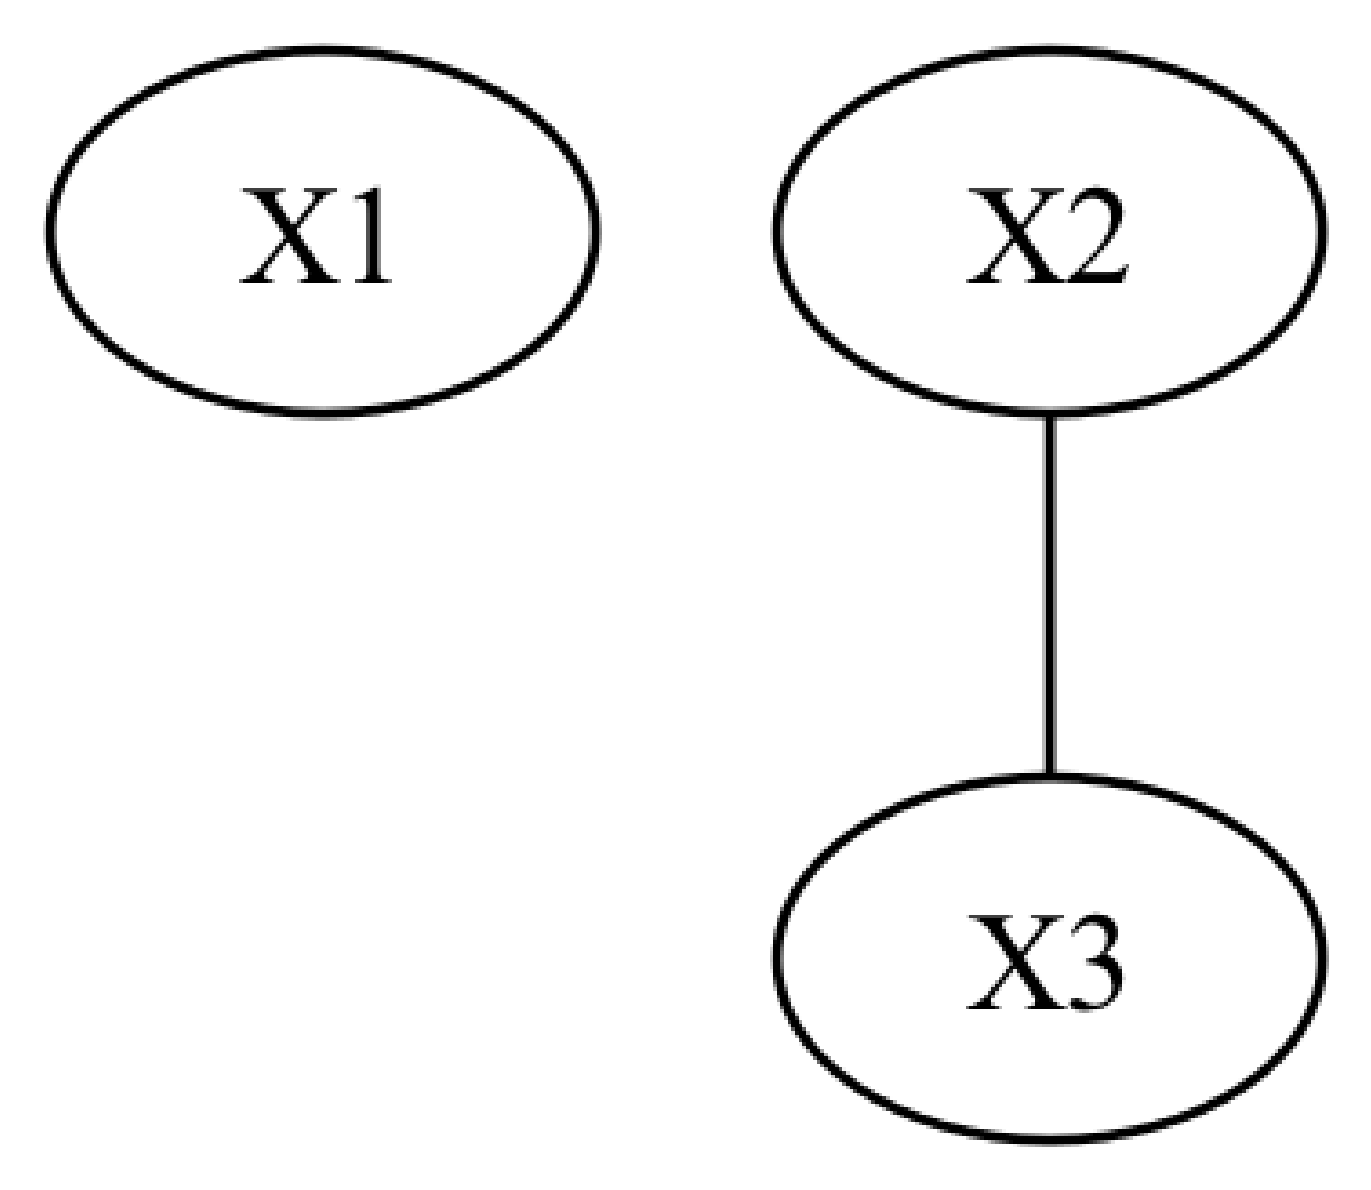

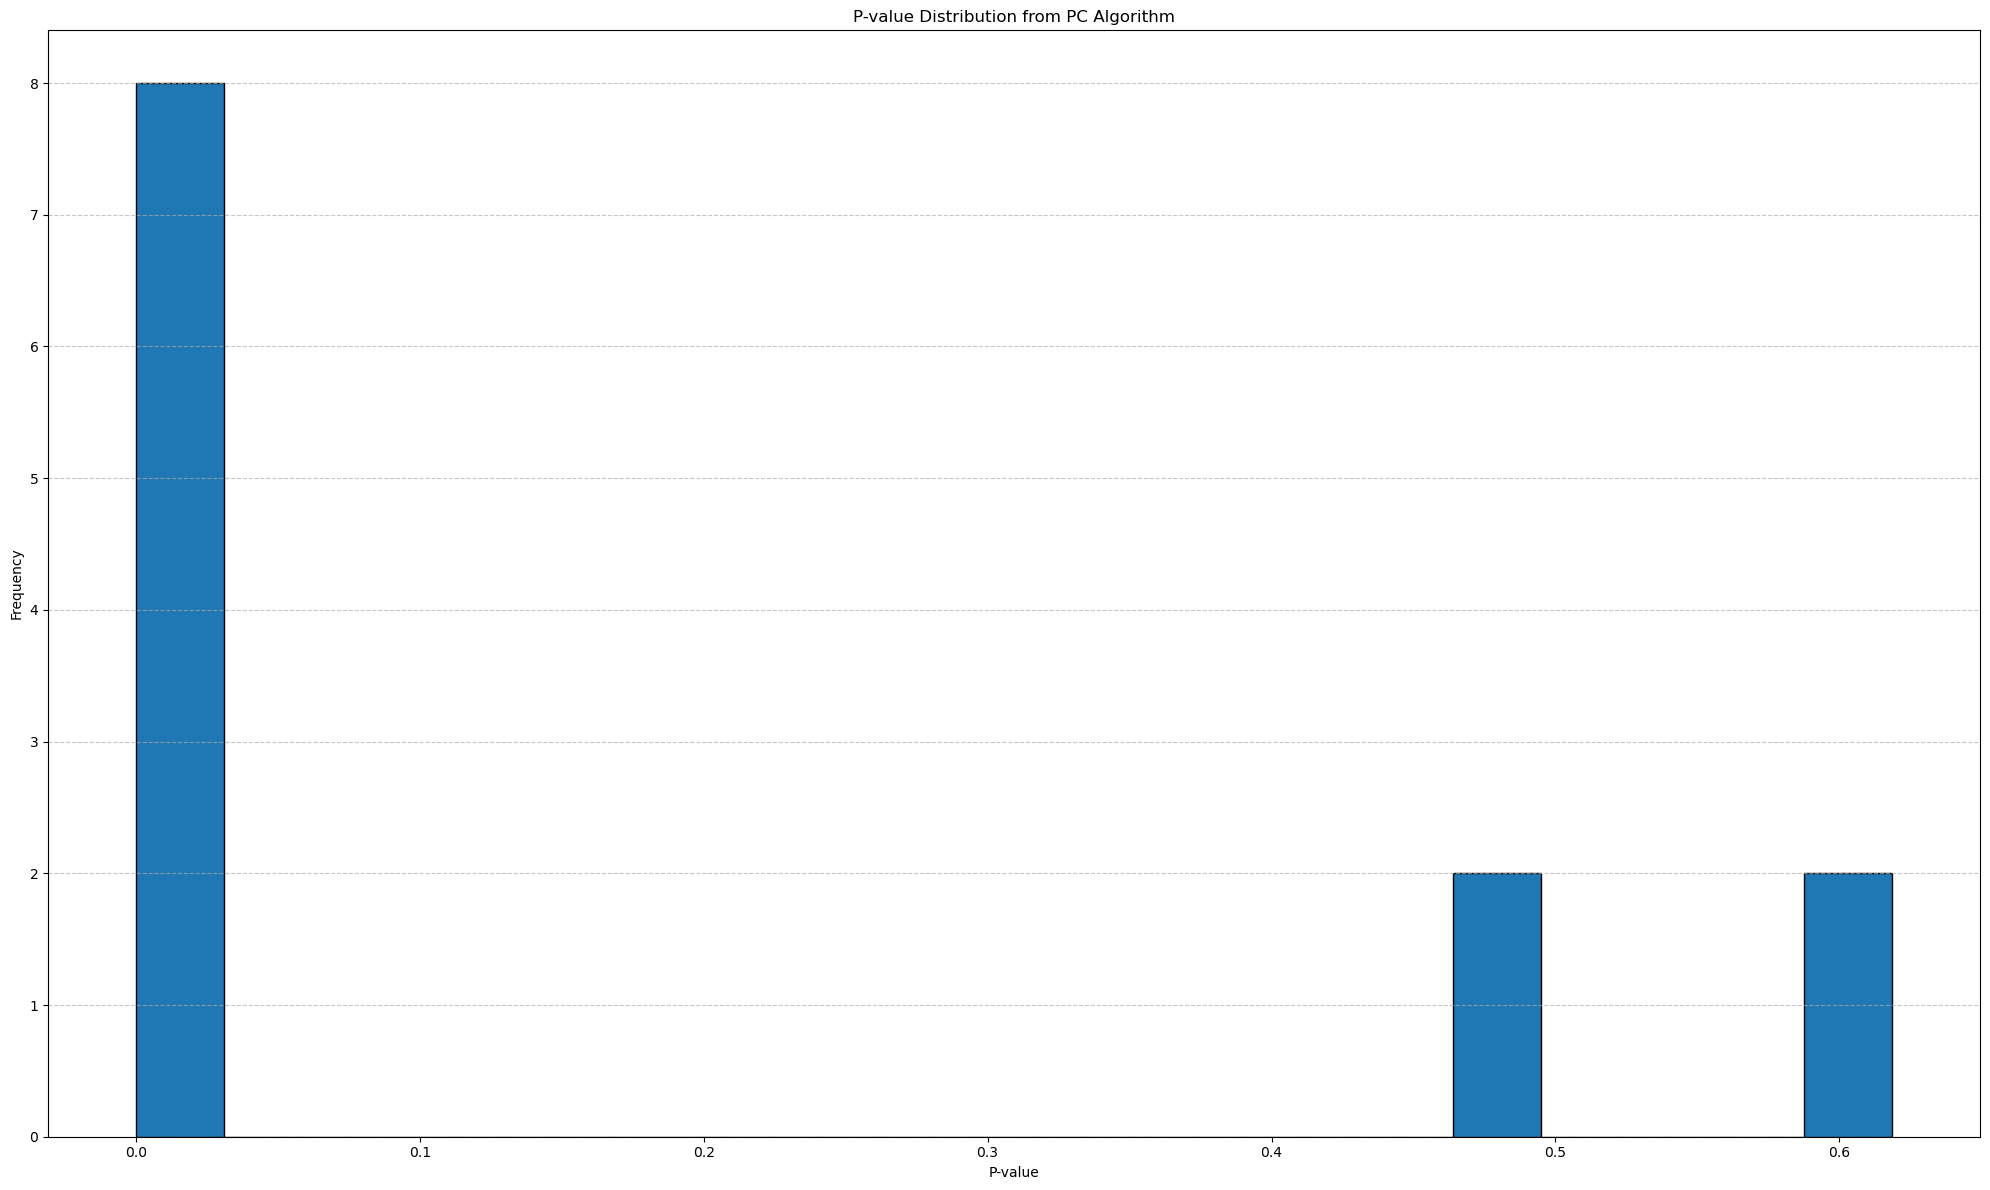

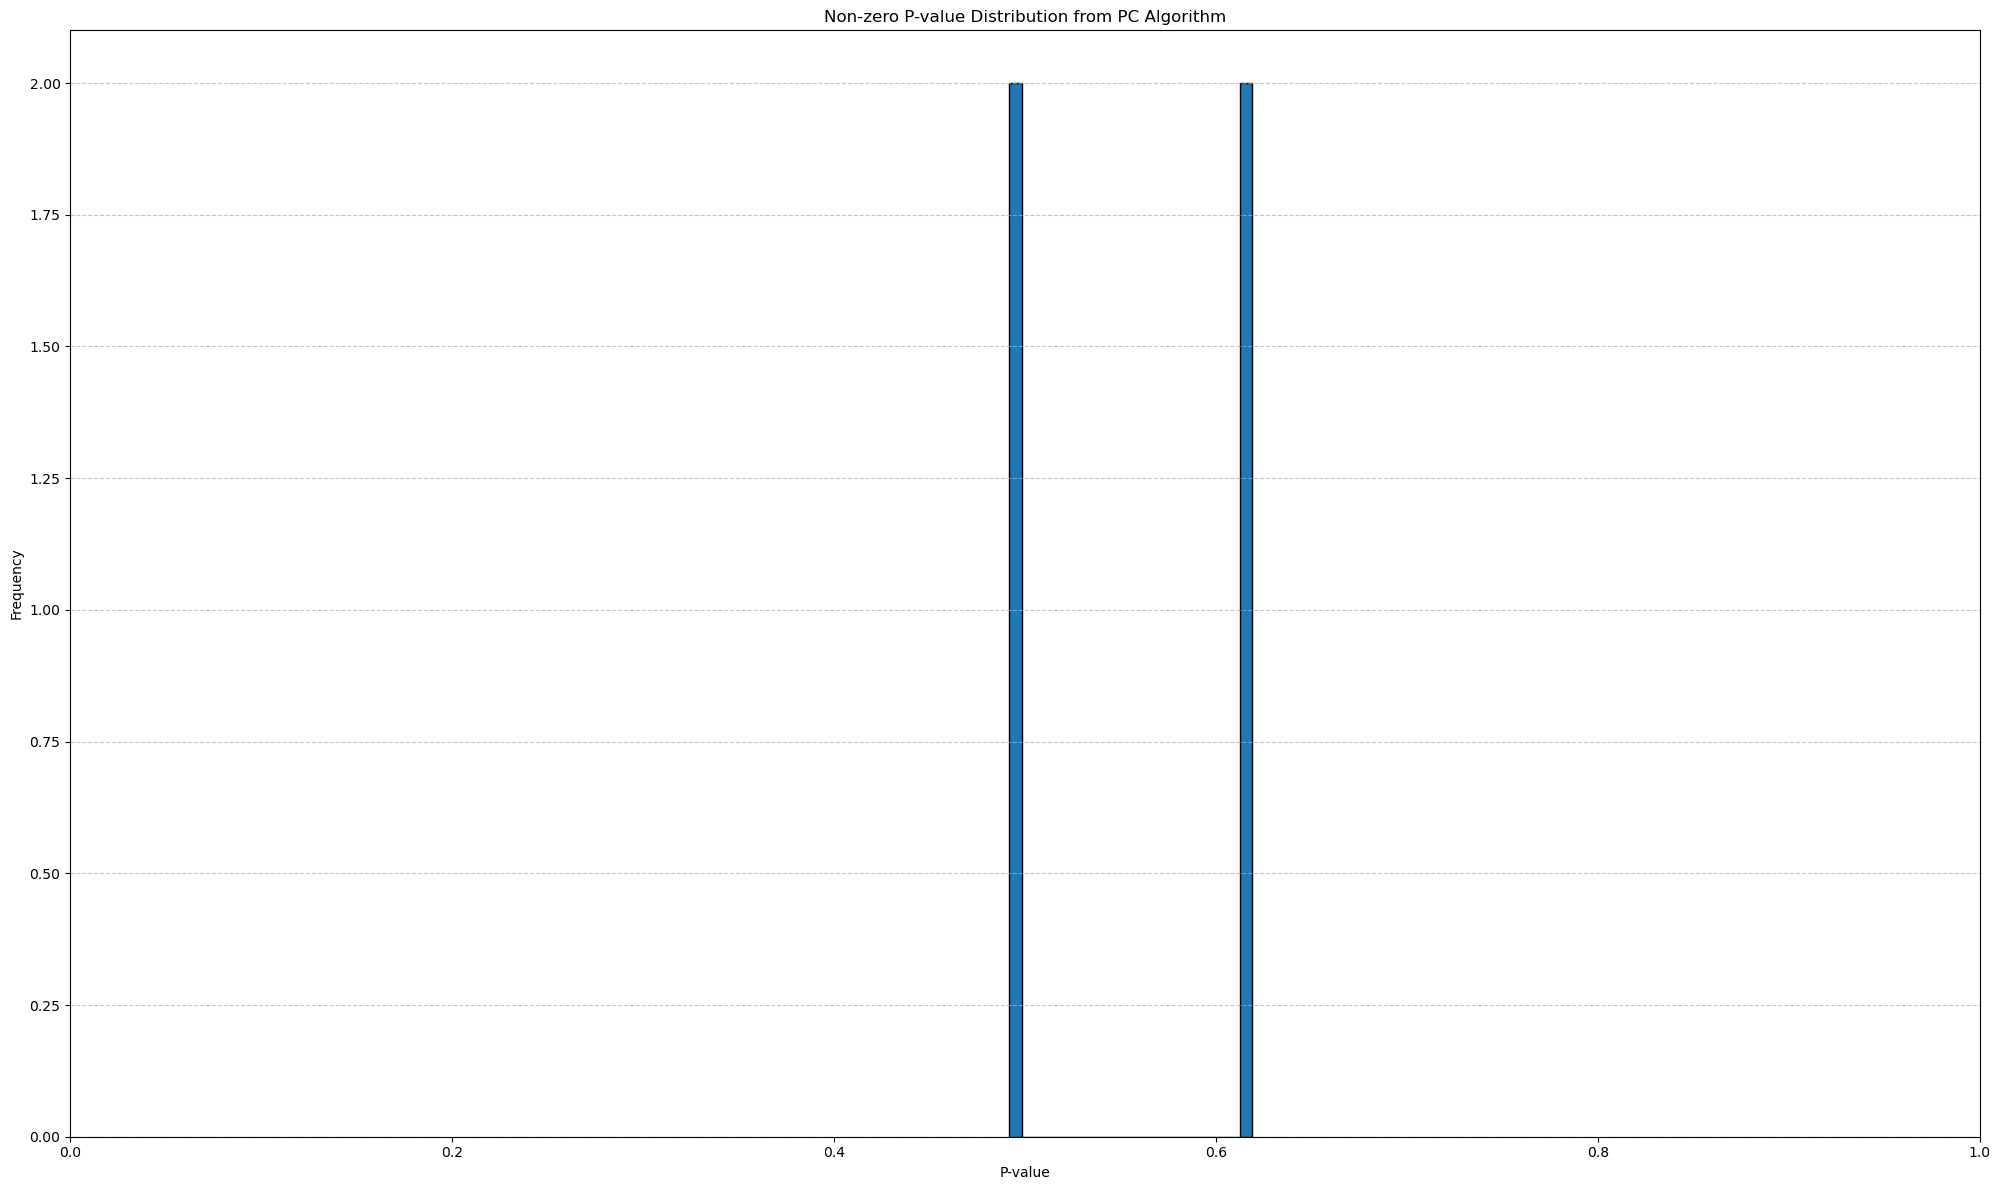

In [47]:
p_values, cg = extract_p_values(data, alpha=0.05, indep_test='fisherz')
cg.draw_pydot_graph()

plot_p_value_distribution(p_values)
plot_non_zero_p_value_distribution(p_values)

  0%|          | 0/100 [00:00<?, ?it/s]

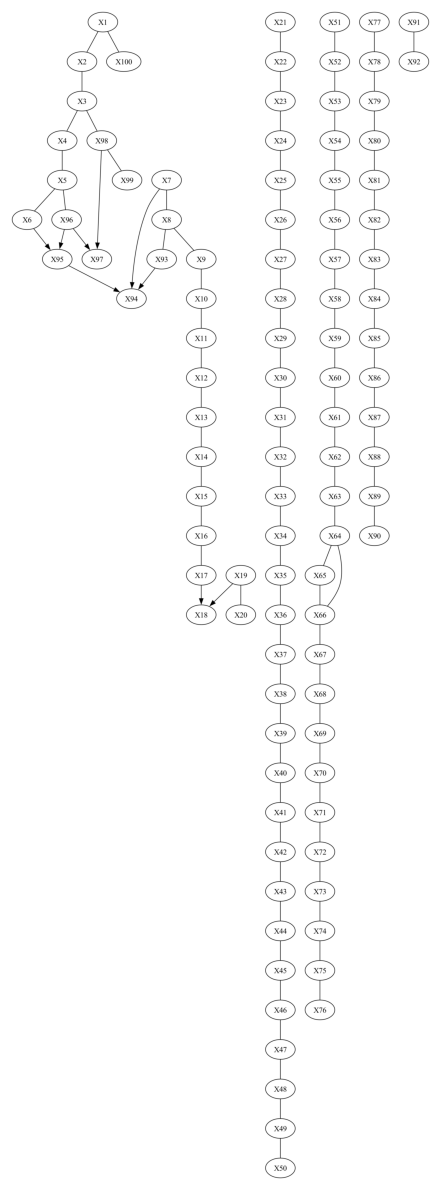

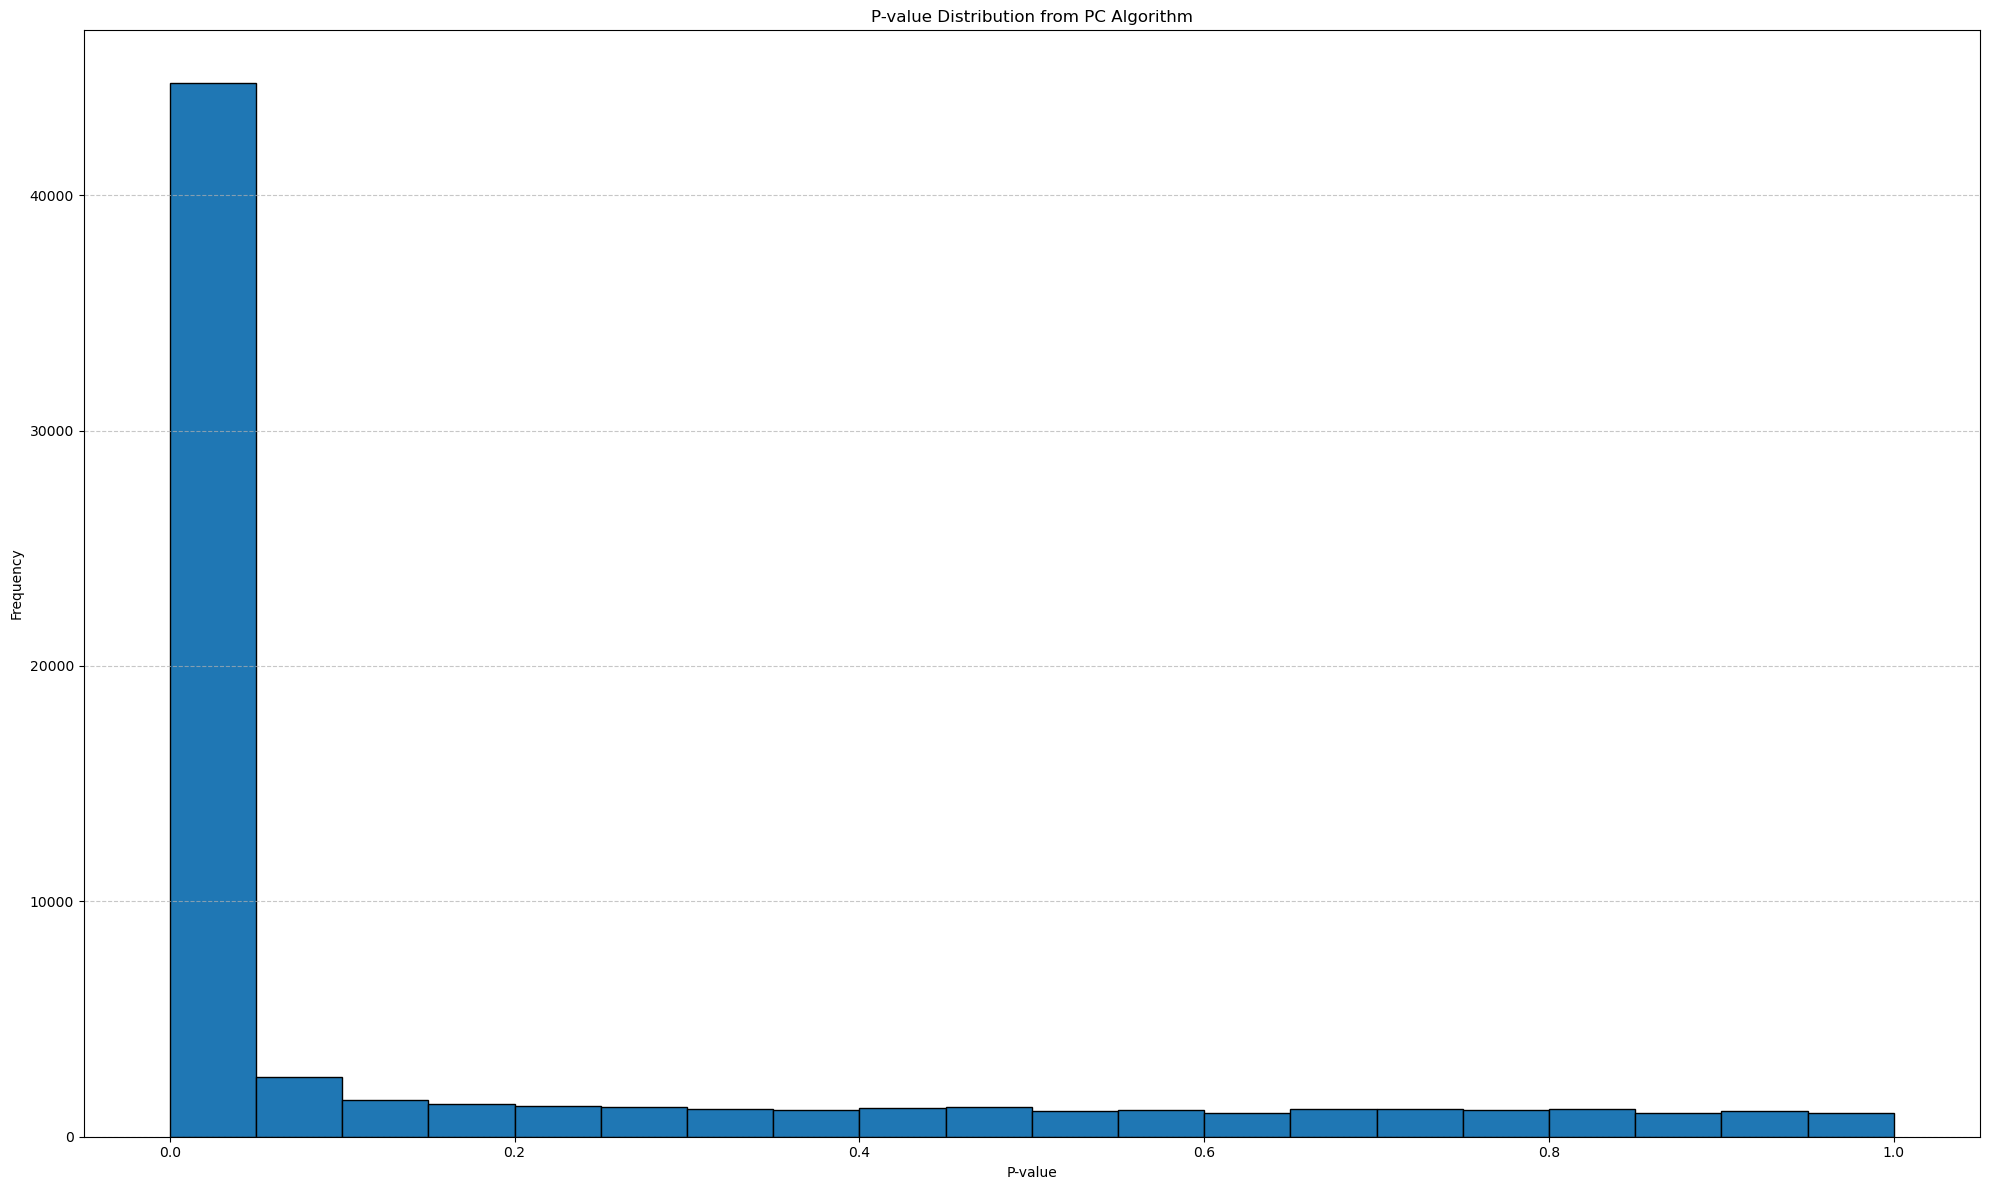

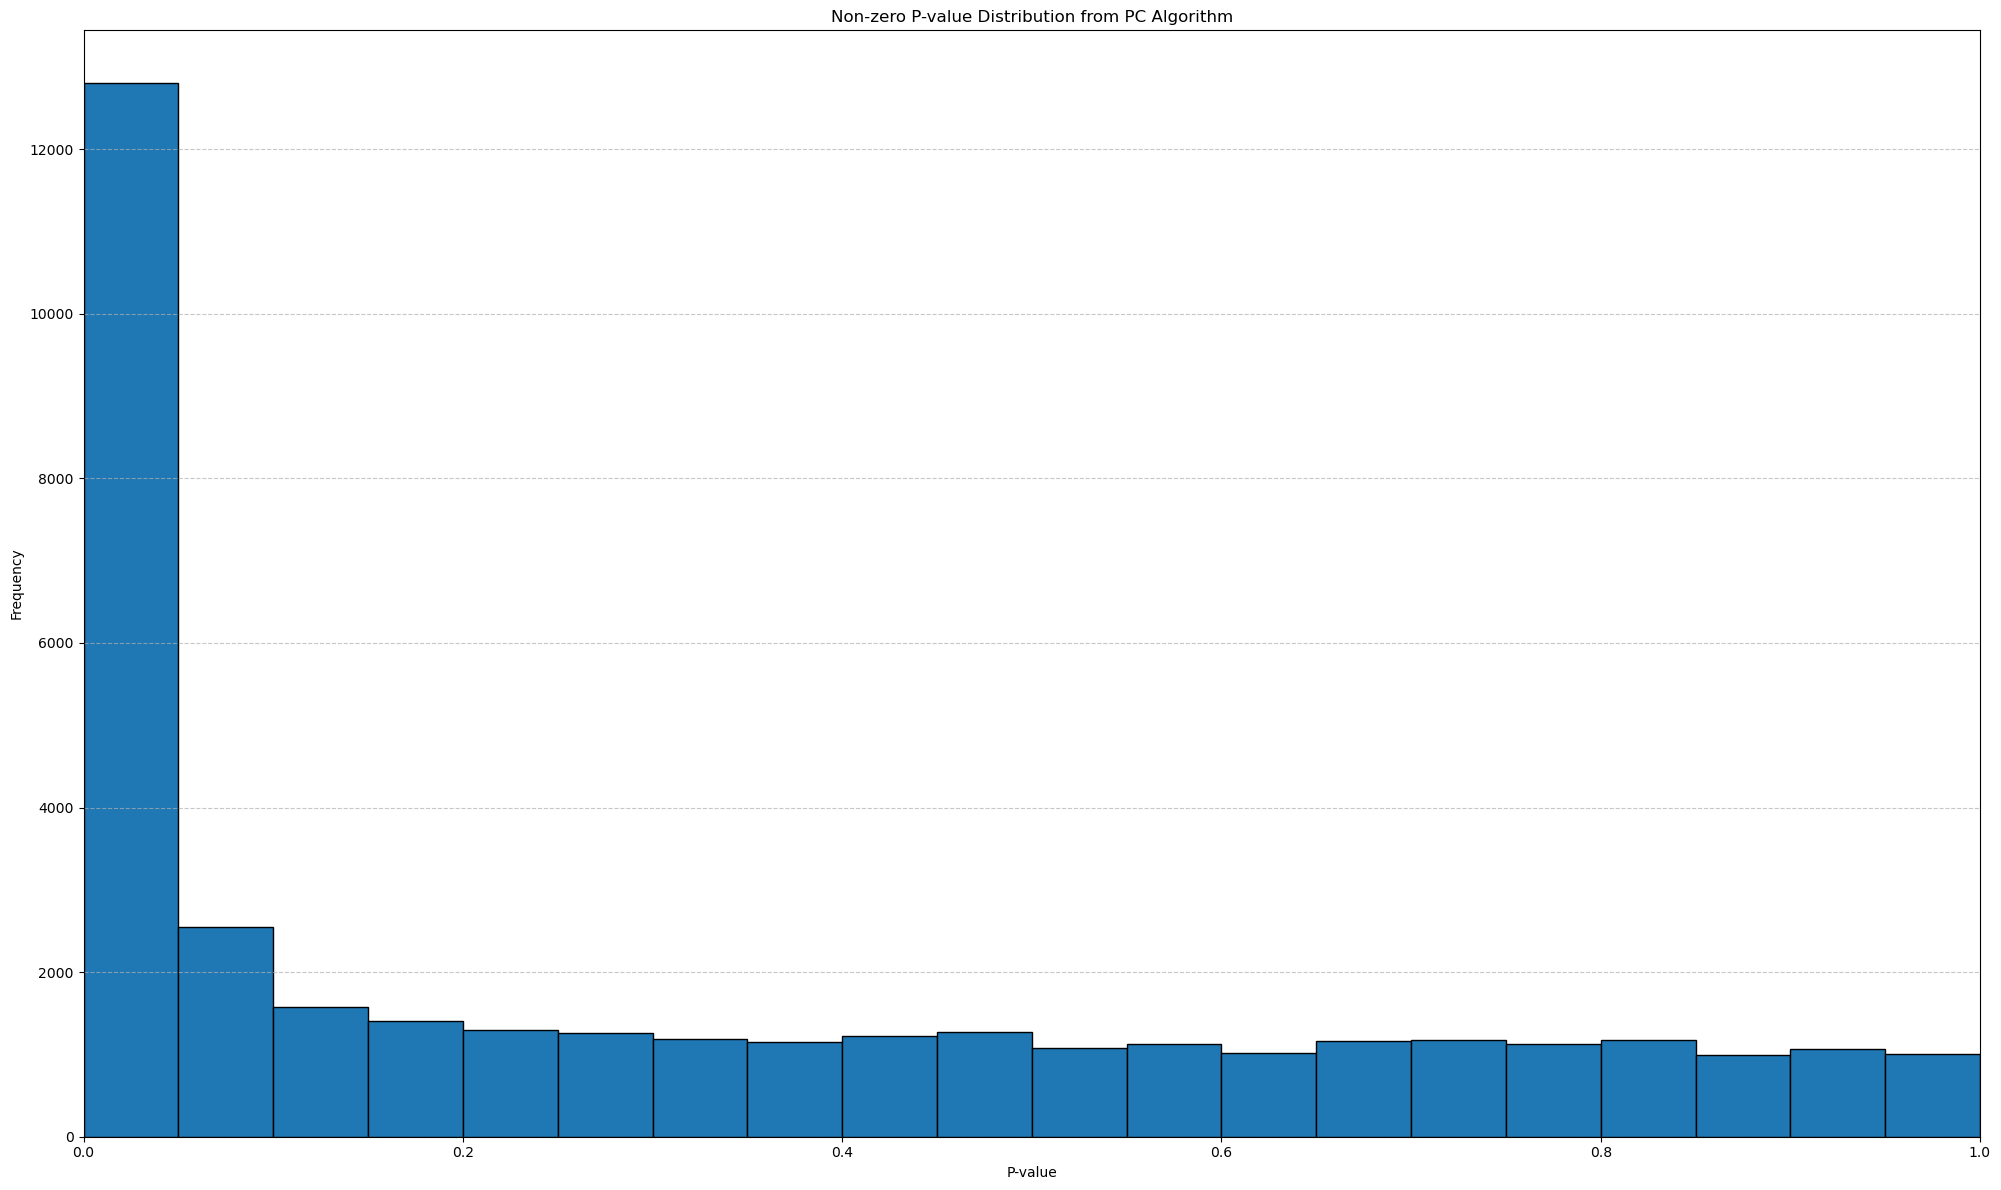

In [48]:
project_root = Path('./').resolve().parents[2]
base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J', 'dataGen','loop100data')
meta_file = os.path.join(base_dir, 'dag2dataset1.csv')
data = pd.read_csv(meta_file).to_numpy()

p_values, cg = extract_p_values(data, alpha=0.05, indep_test='fisherz')
cg.draw_pydot_graph()

plot_p_value_distribution(p_values)
plot_non_zero_p_value_distribution(p_values)

  0%|          | 0/10 [00:00<?, ?it/s]

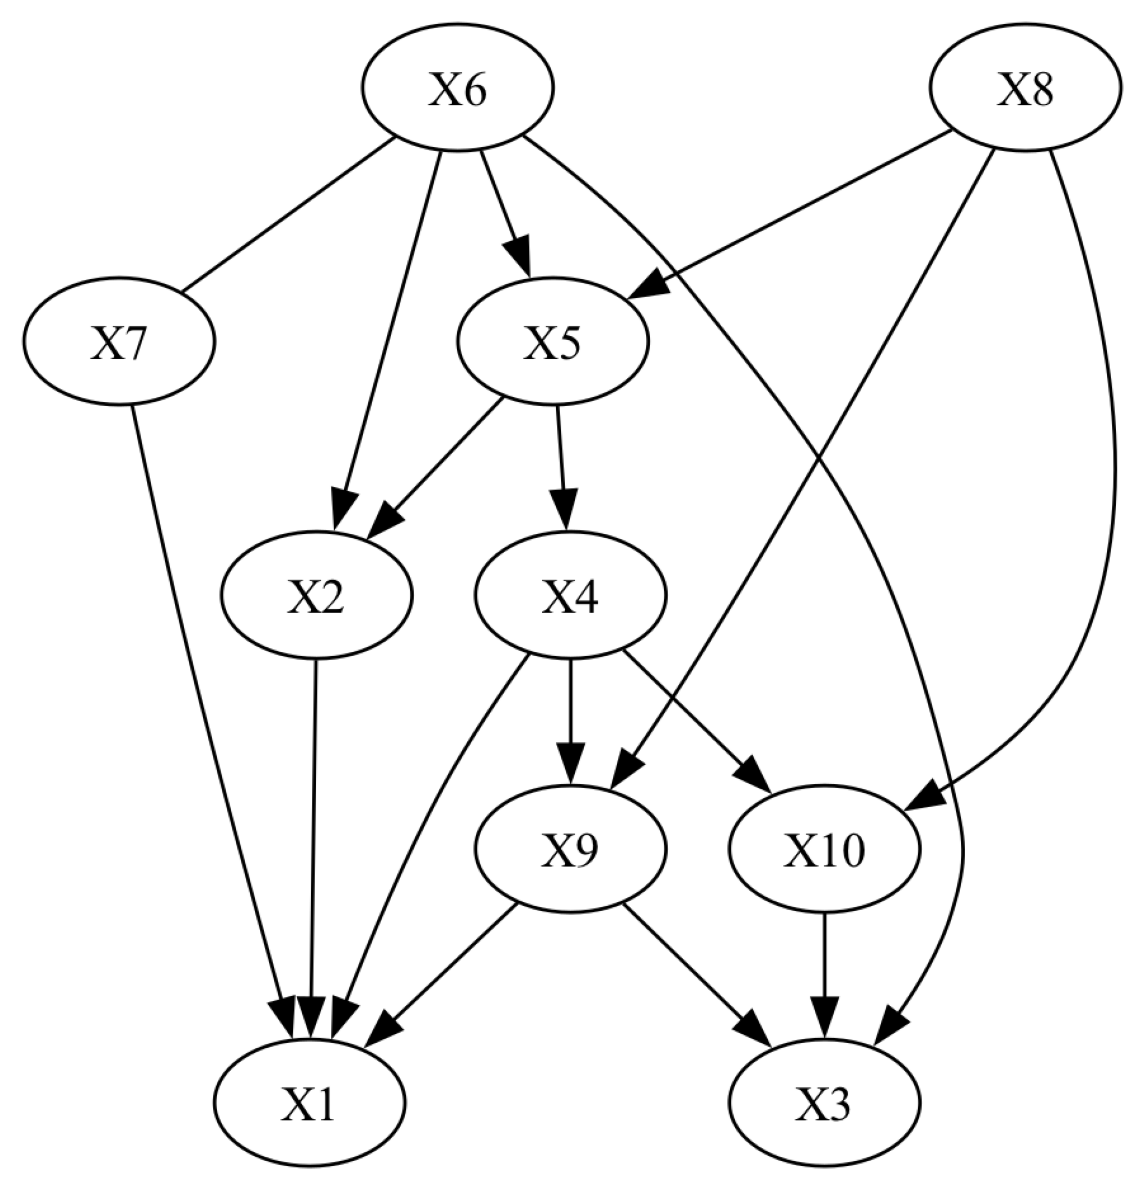

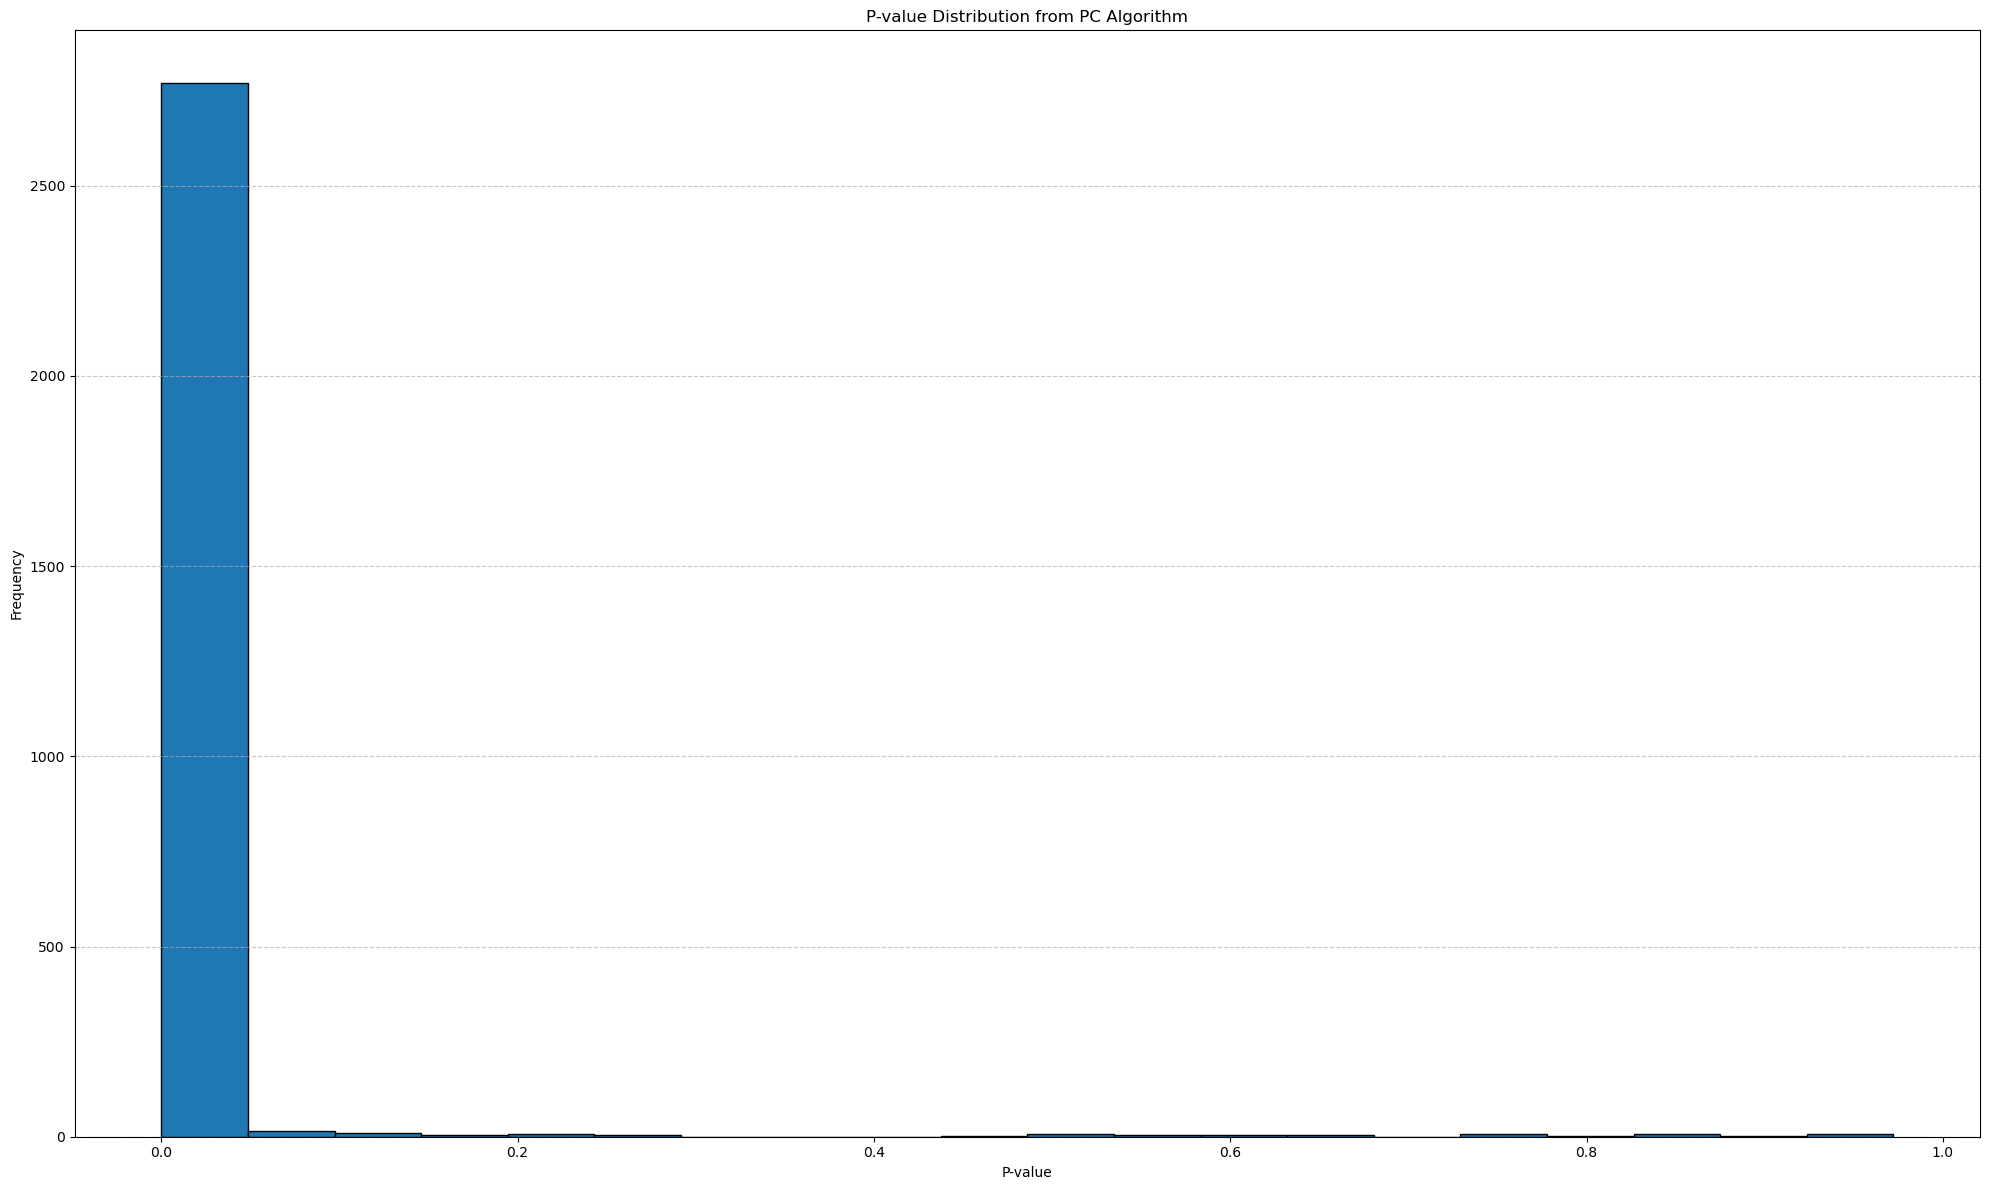

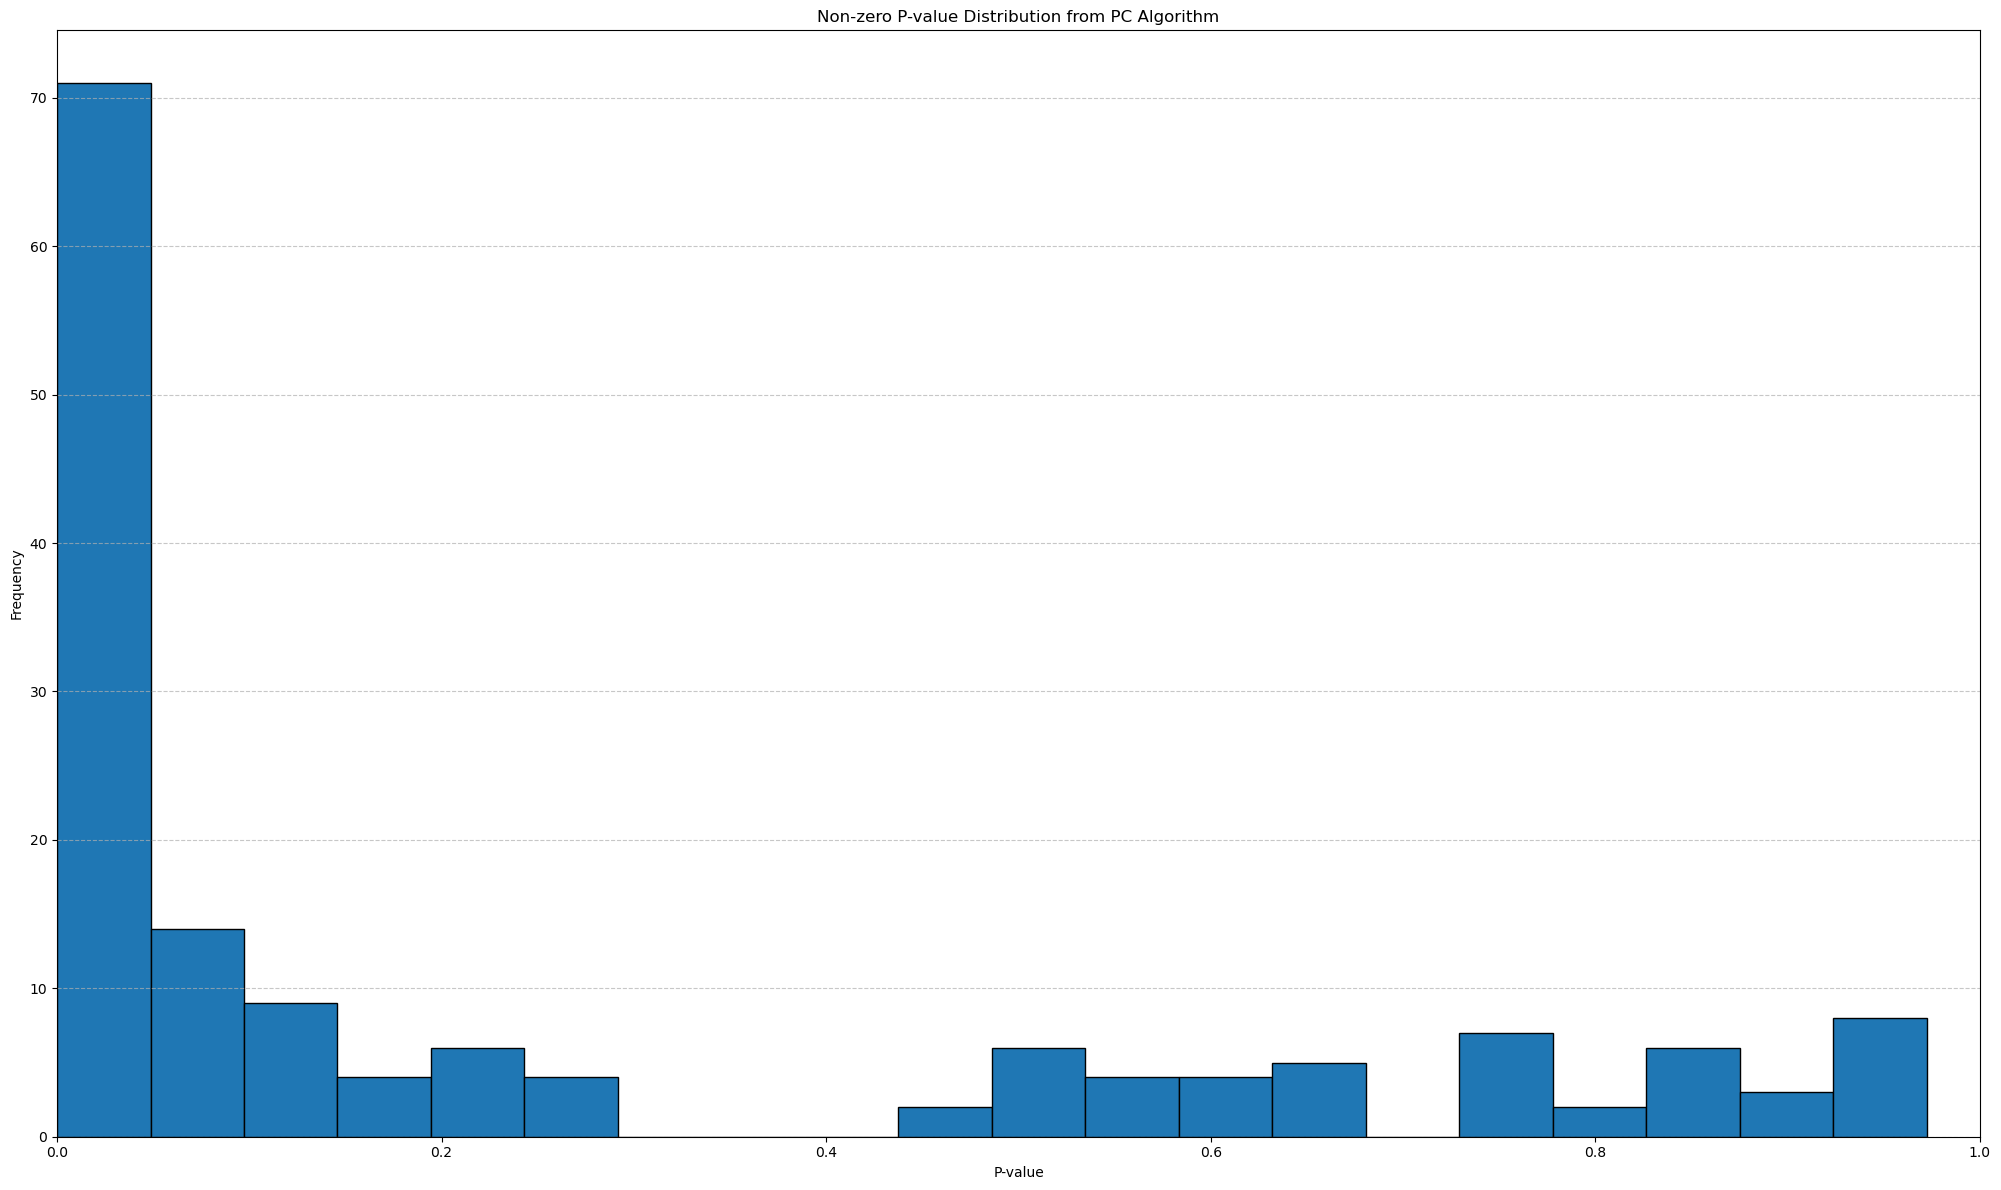

In [49]:
project_root = Path('./').resolve().parents[2]
base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J', 'dataGen')
meta_file = os.path.join(base_dir, 'multivariate_normal_data.csv')
data = pd.read_csv(meta_file).to_numpy()

p_values, cg = extract_p_values(data, alpha=0.05, indep_test='fisherz')
cg.draw_pydot_graph()

plot_p_value_distribution(p_values)
plot_non_zero_p_value_distribution(p_values)